<a href="https://colab.research.google.com/github/FlyAIBox/langchain-academy/blob/fly101/module-3/breakpoints.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![在 Colab 中打开](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-3/breakpoints.ipynb) [![在 LangChain Academy 中打开](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239469-lesson-2-breakpoints)

# 断点（Breakpoints）

## 回顾

在 `人机协作（human-in-the-loop）` 场景中，我们经常希望在图执行过程中查看输出结果。

我们已经在流式处理中为此奠定了基础。

## 学习目标

现在，让我们讨论 `人机协作` 的动机：

(1) **审批（Approval）** - 我们可以中断智能体，向用户展示状态，并允许用户接受某个操作

(2) **调试（Debugging）** - 我们可以回退图执行来重现或避免问题

(3) **编辑（Editing）** - 您可以修改状态

LangGraph 提供了多种方式来获取或更新智能体状态，以支持各种 `人机协作` 工作流。

首先，我们将介绍[断点](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/breakpoints/#simple-usage)，它提供了一种在特定步骤停止图执行的简单方法。

我们将展示这如何实现用户 `审批` 功能。

In [1]:
# 安装必要的依赖包
# 使用 %%capture 隐藏安装过程的输出信息
%%capture --no-stderr
# %pip install --quiet -U langgraph langchain_openai langgraph_sdk langgraph-prebuilt
%pip install --quiet langgraph==0.6.7 langchain_openai==0.3.32 langchain_core==0.3.75 langgraph_sdk==0.2.6 langgraph-prebuilt==0.6.4

In [2]:
# 导入必要的模块
import os, getpass

def _set_env(var: str):
    """
    设置环境变量的辅助函数
    如果环境变量不存在，则提示用户输入
    """
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

# 设置 OpenAI API 密钥
# 这是使用 OpenAI 模型所必需的
_set_env("OPENAI_API_KEY")
# 设置 OpenAI API代理地址 (例如：https://api.apiyi.com/v1）
_set_env("OPENAI_BASE_URL")

OPENAI_API_KEY: ··········
OPENAI_BASE_URL: ··········


## 用于人工审批的断点

让我们重新考虑在模块1中使用的简单智能体。

假设我们关心工具的使用：我们希望审批智能体使用其任何工具。

我们只需要在编译图时使用 `interrupt_before=["tools"]`，其中 `tools` 是我们的工具节点。

这意味着执行将在 `tools` 节点之前被中断，该节点负责执行工具调用。

In [3]:
# 导入 OpenAI 聊天模型
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """
    乘法函数：计算两个整数的乘积

    Args:
        a: 第一个整数
        b: 第二个整数
    """
    return a * b

def add(a: int, b: int) -> int:
    """
    加法函数：计算两个整数的和

    Args:
        a: 第一个整数
        b: 第二个整数
    """
    return a + b

def divide(a: int, b: int) -> float:
    """
    除法函数：计算两个整数的商

    Args:
        a: 被除数
        b: 除数
    """
    return a / b

# 定义工具列表，这些函数将被智能体作为工具使用
tools = [add, multiply, divide]

# 初始化 OpenAI 聊天模型
llm = ChatOpenAI(model="gpt-4o")

# 将工具绑定到语言模型，使模型能够调用这些工具
llm_with_tools = llm.bind_tools(tools)

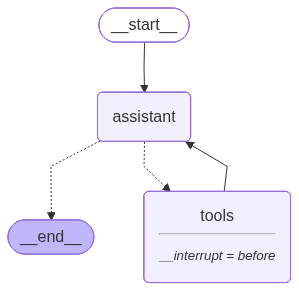

In [4]:
# 导入必要的模块
from IPython.display import Image, display

# 导入 LangGraph 相关模块
from langgraph.checkpoint.memory import MemorySaver  # 内存检查点保存器
from langgraph.graph import MessagesState  # 消息状态类型
from langgraph.graph import START, StateGraph  # 图构建相关
from langgraph.prebuilt import tools_condition, ToolNode  # 预构建的工具节点和条件

# 导入 LangChain 消息类型
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# 定义系统消息，指导智能体的行为
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# 定义智能体节点函数
def assistant(state: MessagesState):
    """
    智能体节点：处理用户输入并决定是否需要调用工具

    Args:
        state: 包含消息历史的状态对象

    Returns:
        包含新消息的字典
    """
    # 将系统消息和用户消息一起发送给语言模型
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# 创建状态图构建器
builder = StateGraph(MessagesState)

# 定义节点：这些节点执行具体的工作
builder.add_node("assistant", assistant)  # 智能体节点
builder.add_node("tools", ToolNode(tools))  # 工具执行节点

# 定义边：这些边决定控制流程
builder.add_edge(START, "assistant")  # 从开始到智能体

# 添加条件边：根据智能体的输出决定下一步
builder.add_conditional_edges(
    "assistant",
    # 如果智能体的最新消息是工具调用 -> tools_condition 路由到 tools 节点
    # 如果智能体的最新消息不是工具调用 -> tools_condition 路由到 END
    tools_condition,
)
builder.add_edge("tools", "assistant")  # 从工具节点回到智能体

# 创建内存检查点保存器
memory = MemorySaver()

# 编译图，设置断点在 "tools" 节点之前
# interrupt_before=["tools"] 表示在执行 tools 节点之前会中断
graph = builder.compile(interrupt_before=["tools"], checkpointer=memory)

# 显示图的可视化结构
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [5]:
# 定义初始输入：用户要求计算 2 乘以 3
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# 创建线程配置，用于跟踪对话状态
thread = {"configurable": {"thread_id": "1"}}

# 运行图直到第一个中断点
# 由于设置了 interrupt_before=["tools"]，执行会在 tools 节点之前停止
for event in graph.stream(initial_input, thread, stream_mode="values"):
    # 打印最新的消息内容
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_paOosxIg3dOQUybOGHcTUkOd)
 Call ID: call_paOosxIg3dOQUybOGHcTUkOd
  Args:
    a: 2
    b: 3


我们可以获取状态并查看下一个要调用的节点。

这是查看图是否已被中断的好方法。

In [6]:
# 获取当前图的状态
state = graph.get_state(thread)

# 查看下一个要执行的节点
# 这应该显示 ('tools',) 表示下一个要执行的是 tools 节点
state.next

('tools',)

现在，我们将介绍一个巧妙的技巧。

当我们使用 `None` 调用图时，它将从最后一个状态检查点继续执行！

![断点示意图](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbae7985b747dfed67775d_breakpoints1.png)

为了清晰起见，LangGraph 将重新发出当前状态，其中包含带有工具调用的 `AIMessage`。

然后它将继续执行图中的后续步骤，从工具节点开始。

我们看到工具节点使用这个工具调用运行，然后结果被传递回聊天模型以获得最终答案。

In [7]:
# 使用 None 作为输入继续执行图
# 这将从上次中断的地方继续执行
for event in graph.stream(None, thread, stream_mode="values"):
    # 打印最新的消息内容
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (call_paOosxIg3dOQUybOGHcTUkOd)
 Call ID: call_paOosxIg3dOQUybOGHcTUkOd
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The product of 2 and 3 is 6.


现在，让我们将这些功能与一个接受用户输入的特定用户审批步骤结合起来。

In [8]:
# 定义初始输入：用户要求计算 2 乘以 3
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# 创建新的线程配置
thread = {"configurable": {"thread_id": "2"}}

# 运行图直到第一个中断点
print("=== 执行到断点 ===")
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

# 获取用户反馈
print("\n=== 等待用户审批 ===")
user_approval = input("您是否要调用工具？(yes/no): ")

# 检查审批结果
if user_approval.lower() == "yes":
    print("\n=== 用户批准，继续执行 ===")
    # 如果批准，继续执行图
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()

else:
    print("操作已被用户取消。")

=== 执行到断点 ===
================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_RPcjBwTaDzu53pWY8Jl00S1B)
 Call ID: call_RPcjBwTaDzu53pWY8Jl00S1B
  Args:
    a: 2
    b: 3

=== 等待用户审批 ===
您是否要调用工具？(yes/no): no
操作已被用户取消。


### 使用 LangGraph API 的断点

**⚠️ 免责声明**

自这些视频录制以来，我们已经更新了 Studio，使其可以在本地运行并在浏览器中打开。这是现在运行 Studio 的首选方式（而不是使用视频中显示的桌面应用程序）。请参阅[本地开发服务器](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/#local-development-server)的文档和[运行开发服务器](https://langchain-ai.github.io/langgraph/how-tos/local-studio/#run-the-development-server)的文档。要启动本地开发服务器，请在此模块的 `/studio` 目录中的终端运行以下命令：

```
langgraph dev
```

您应该看到以下输出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

打开浏览器并导航到 Studio UI：`https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024`。

LangGraph API [支持断点](https://langchain-ai.github.io/langgraph/cloud/how-tos/human_in_the_loop_breakpoint/#sdk-initialization)。

In [9]:
# 检查是否在 Google Colab 环境中运行
# 如果是，则抛出异常，因为 LangGraph Studio 目前不支持 Google Colab
if 'google.colab' in str(get_ipython()):
    raise Exception("不幸的是，LangGraph Studio 目前不支持 Google Colab")

Exception: 不幸的是，LangGraph Studio 目前不支持 Google Colab

In [ ]:
# 这是本地开发服务器的 URL
from langgraph_sdk import get_client

# 创建 LangGraph SDK 客户端，连接到本地开发服务器
client = get_client(url="http://127.0.0.1:2024")

如上所示，我们可以在编译在 Studio 中运行的图时添加 `interrupt_before=["node"]`。

但是，使用 API 时，您也可以直接将 `interrupt_before` 传递给 stream 方法。

In [ ]:
# 定义初始输入
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# 创建新的线程
thread = await client.threads.create()

# 使用 API 流式运行，在 tools 节点之前中断
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=initial_input,
    stream_mode="values",
    interrupt_before=["tools"],  # 在 tools 节点之前中断
):
    print(f"接收到新事件类型: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

现在，我们可以像之前一样通过传递 `thread_id` 和 `None` 作为输入从断点继续执行！

In [ ]:
# 从断点继续执行
# 使用 None 作为输入，从上次中断的地方继续
async for chunk in client.runs.stream(
    thread["thread_id"],
    "agent",
    input=None,  # 使用 None 从断点继续
    stream_mode="values",
    interrupt_before=["tools"],
):
    print(f"接收到新事件类型: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)